# AAV5 -- vue d'ensemble du dataset brut

Notebook de reference rapide sur `AAV5_organoides.csv` -- pas de filtre, pas de regression,
juste les chiffres de base pour s'orienter :

1. `pandas.describe()` sur toutes les colonnes numeriques.
2. Nombre de reads a chaque etape (checkpoint) -- total, reads/variant (moyenne+mediane, sur
   l'ensemble ET parmi les variants detectes), fraction de variants detectes, table de comptage
   par seuil (`analysisV1.number_of_seq_threshold`).
3. Top 100 sequences par colonne (comptages ET log2 enrichissements).

**Notebook prepare mais jamais execute par Claude** (`feedback_user_runs_notebooks`).

### 0. Setup

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd

_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if p.name == "Modelization_V2")
sys.path.insert(0, str(_root / "lib"))
from analysisV1 import number_of_seq_threshold

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

CSV = Path("AAV5_organoides.csv")
if not CSV.exists():
    CSV = _root / "notebooks/notebooks/AAVs dataset/AAV5/AAV5_organoides.csv"
assert CSV.exists(), CSV

df = pd.read_csv(CSV)
print(f"{CSV.name} : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
df.dtypes

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AAV5_organoides.csv : 5,595,543 lignes x 35 colonnes


sequence                                                str
compte_plasmide                                     float64
compte_virus                                        float64
log2_enrichissement_virus_sur_plasmide              float64
compte_organoide_1_adn                              float64
compte_organoide_1_arn                              float64
log2_enrichissement_organoide_1_adn_sur_virus       float64
log2_enrichissement_organoide_1_arn_sur_virus       float64
log2_enrichissement_organoide_1_arn_sur_adn         float64
compte_organoide_2_adn                              float64
compte_organoide_2_arn                              float64
log2_enrichissement_organoide_2_adn_sur_virus       float64
log2_enrichissement_organoide_2_arn_sur_virus       float64
log2_enrichissement_organoide_2_arn_sur_adn         float64
compte_organoide_3_adn                              float64
compte_organoide_3_arn                              float64
log2_enrichissement_organoide_3_adn_sur_

### 1. `pandas.describe()` -- toutes les colonnes numeriques

Percentiles etendus (`.01`/`.05`/`.95`/`.99` en plus des quartiles par defaut) -- les colonnes de
comptage sont a queue tres lourde, les quartiles seuls masquent la queue.

In [2]:
numeric_cols = df.columns.drop("sequence")
stats = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
stats

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
compte_plasmide,5595543.0,20.679449,2048.463910,0.000000,0.000000,0.000000,7.500000,16.000000,27.500000,53.000000,80.500000,4.845392e+06
compte_virus,5595543.0,31.488647,1335.930630,0.500000,0.500000,0.500000,1.000000,7.000000,21.000000,73.000000,366.500000,3.043832e+06
log2_enrichissement_virus_sur_plasmide,5045045.0,0.076582,2.571946,-8.823937,-4.987056,-4.042909,-1.987056,0.260871,1.909399,4.167762,6.118852,1.115720e+01
compte_organoide_1_adn,5595543.0,7.374865,955.215552,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,2.138988e+06
compte_organoide_1_arn,5595543.0,6.835370,354.539266,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.467165e+05
log2_enrichissement_organoide_1_adn_sur_virus,108370.0,-0.541526,4.353662,-13.209836,-8.915061,-7.280723,-3.897699,-0.551248,2.307860,7.036938,10.431864,1.647051e+01
log2_enrichissement_organoide_1_arn_sur_virus,81092.0,-0.389442,4.451082,-12.752768,-9.182908,-7.450924,-3.866615,-0.064518,2.690369,6.978065,10.533337,1.687589e+01
log2_enrichissement_organoide_1_arn_sur_adn,47320.0,0.045716,5.771467,-12.755909,-10.697759,-9.744869,-1.891558,0.112335,2.434263,9.296013,10.313730,1.236323e+01
compte_organoide_2_adn,5595543.0,8.414846,1097.808592,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.500000,85.500000,2.446622e+06
compte_organoide_2_arn,5595543.0,7.317130,399.886405,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.943625e+05


### 2. Reads a chaque etape (checkpoint)

Une ligne par colonne `compte_*` (chaque colonne = un checkpoint : plasmide = librairie
initiale, virus = post-viabilite, organoide/noyaux = post-selectivite par replicat/compartiment).
`reads/variant` a deux variantes : sur TOUT le dataset (total_reads / n_lignes -- inclut les
variants a 0) et parmi les variants REELEMENT detectes (`count>0`) -- l'ecart entre les deux
mesure directement la severite de l'attrition a ce checkpoint.

In [3]:
count_cols = [c for c in df.columns if c.startswith("compte_")]
n_total = len(df)

reads_summary = pd.DataFrame({
    c: {
        "total_reads": int(df[c].sum()),
        "reads/variant (tout le dataset)": df[c].sum() / n_total,
        "n_variants>0": int((df[c] > 0).sum()),
        "fraction>0": (df[c] > 0).mean(),
        "reads/variant (parmi >0), moyenne": df.loc[df[c] > 0, c].mean(),
        "reads/variant (parmi >0), mediane": df.loc[df[c] > 0, c].median(),
    }
    for c in count_cols
}).T
reads_summary

,total_reads,reads/variant (tout le dataset),n_variants>0,fraction>0,"reads/variant (parmi >0), moyenne","reads/variant (parmi >0), mediane"
compte_plasmide,115712748.0,20.679449,5045045.0,0.901618,22.935920,17.5
compte_virus,176196080.0,31.488647,5595543.0,1.000000,31.488647,7.0
compte_organoide_1_adn,41266372.0,7.374865,108370.0,0.019367,380.791474,2.0
compte_organoide_1_arn,38247606.0,6.835370,81092.0,0.014492,471.656958,2.0
compte_organoide_2_adn,47085630.0,8.414846,486844.0,0.087006,96.716054,17.5
compte_organoide_2_arn,40943315.0,7.317130,78570.0,0.014042,521.106211,2.0
compte_organoide_3_adn,43130572.0,7.708023,233974.0,0.041814,184.339168,49.0
compte_organoide_3_arn,39808479.0,7.114319,87657.0,0.015666,454.139196,58.5
compte_noyaux_1_adn,39667684.0,7.089157,74359.0,0.013289,533.461780,6.0
compte_noyaux_1_arn,50441062.0,9.014507,45595.0,0.008148,1106.284954,1.5


In [4]:
thresholds_table = number_of_seq_threshold(
    lambdas={c: df[c].to_numpy() for c in count_cols},
    thresholds=[1, 10, 100, 1000],
)
thresholds_table

,1.0,10.0,100.0,1000.0
lambda,,,,
compte_plasmide,5029666,3822626,20067,37
compte_virus,5032609,2430484,184962,20314
compte_organoide_1_adn,101212,31026,26461,10174
compte_organoide_1_arn,75532,21705,19751,8855
compte_organoide_2_adn,480777,322335,48774,6235
compte_organoide_2_arn,73402,26736,24199,9430
compte_organoide_3_adn,228722,181066,57589,6182
compte_organoide_3_arn,82871,48787,37883,8370
compte_noyaux_1_adn,69331,35890,33124,7686


### 3. Top 100 sequences par colonne

Un `nlargest(100, colonne)` pour chaque colonne numerique (comptages ET log2 enrichissements) --
stocke integralement dans `top100[colonne]` (100 lignes chacun), seul le top 10 est affiche ici
pour rester lisible.

In [5]:
value_cols = [c for c in df.columns if c != "sequence"]
top100 = {c: df.nlargest(100, c)[["sequence", c]].reset_index(drop=True) for c in value_cols}
print(f"top100 calcule pour {len(top100)} colonnes -- top100['<colonne>'] pour les 100 lignes completes")

top100 calcule pour 34 colonnes -- top100['<colonne>'] pour les 100 lignes completes


In [6]:
for c in value_cols:
    print(f"--- top 10 (sur 100 calcules) : {c} ---")
    display(top100[c].head(10))

--- top 10 (sur 100 calcules) : compte_plasmide ---


,sequence,compte_plasmide
0,LGETTRP,4845391.5
1,LGETTRH,16921.5
2,TPANSTK,12492.5
3,LCETTRP,7071.0
4,LGETTIP,6615.5
5,IADNRVS,3480.0
6,NHPNSID,3364.0
7,LPENSID,3001.5
8,TTKKNSE,2177.5
9,HLSNSID,2124.5


--- top 10 (sur 100 calcules) : compte_virus ---


,sequence,compte_virus
0,LGETTRP,3043832.5
1,IADNRVS,361759.5
2,NHPNSID,329851.0
3,HDNKIMK,185091.0
4,LNTTRLT,157991.5
5,KPMNATN,99325.0
6,QKTHSQT,98226.5
7,HDINLTK,88038.0
8,INQANRV,80227.5
9,INLDLTK,77159.0


--- top 10 (sur 100 calcules) : log2_enrichissement_virus_sur_plasmide ---


...

,sequence,log2_enrichissement_noyaux_moyenne_arn_sur_virus
0,MRHIVGQ,16.801438
1,LRDHKLT,16.622981
2,STTDHRH,16.574073
3,QLRNHAS,16.535367
4,KPTQPHV,16.389384
5,SPMTPMR,15.939403
6,GRATHPP,15.848231
7,HVKVAPQ,15.734911
8,GGAKQHA,15.600462
9,ADSAKST,15.589570


--- top 10 (sur 100 calcules) : log2_enrichissement_noyaux_moyenne_arn_sur_adn ---


,sequence,log2_enrichissement_noyaux_moyenne_arn_sur_adn
0,TPGINMK,14.663228
1,VDVEMKQ,14.302620
2,IPGTRAT,14.290309
3,RLGLTNM,14.156270
4,KGKRELT,14.123626
5,EKGKSGI,13.811543
6,SVTARNH,13.791270
7,VHSQLRN,13.765317
8,THSKTAT,13.578075
9,SPHKLAH,13.570888


--- top 10 (sur 100 calcules) : compte_controle_negatif ---


,sequence,compte_controle_negatif
0,VRVRAVE,648118.0
1,TQAGVHK,340877.0
2,LGETTRP,336622.5
3,VKSLPPT,144544.5
4,TKKTLPP,134767.5
5,HDNKIMK,130615.0
6,LNRPLQT,122055.0
7,AKSNPKT,105314.5
8,TKLVMKQ,103720.0
9,HLSNSID,102468.0


### 4. Org1 vs org2 vs org3 -- accord entre replicats (log2 enrichissement organoide ADN/virus)

Scatter pairwise (hexbin + diagonale y=x + Pearson r) sur les 3 colonnes
`log2_enrichissement_organoide_{1,2,3}_adn_sur_virus` -- tout le dataset, seule contrainte : les
deux valeurs finies pour la paire consideree (pas de filtre supplementaire).

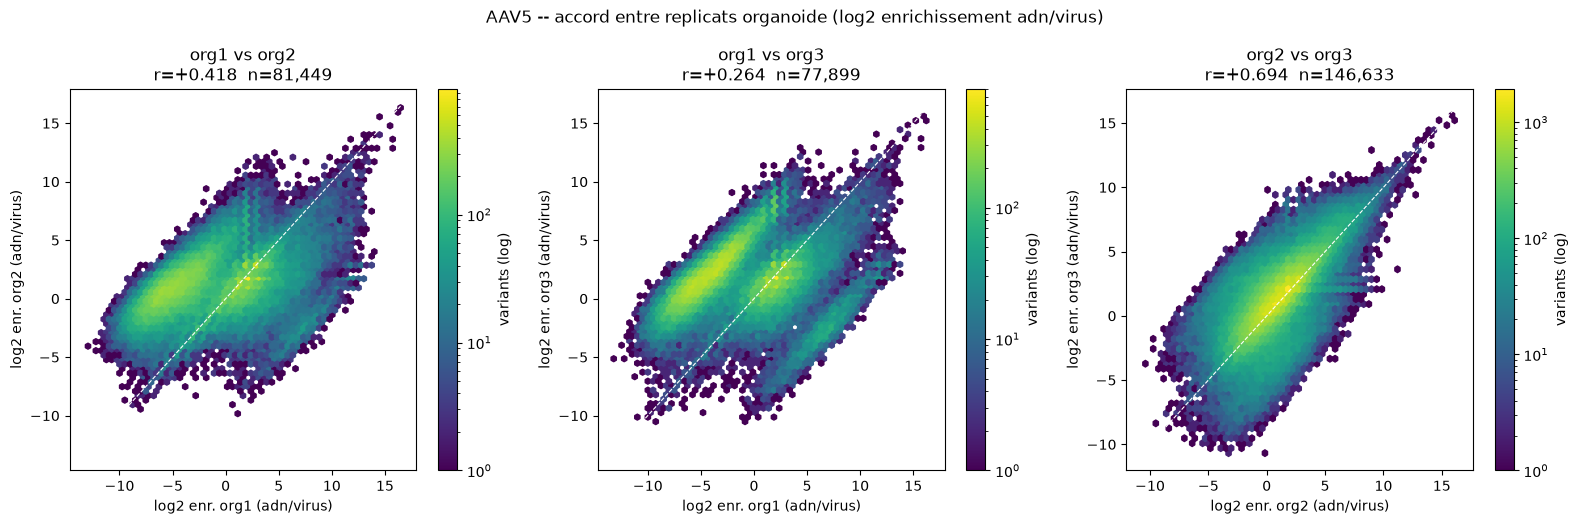

In [7]:
import matplotlib.pyplot as plt
from itertools import combinations
from analysisV1 import pearson

org_cols = {i: f"log2_enrichissement_organoide_{i}_adn_sur_virus" for i in (1, 2, 3)}

fig, axes = plt.subplots(1, 3, figsize=(16, 5.3))
for ax, (i, j) in zip(axes, combinations(org_cols, 2)):
    xi = df[org_cols[i]].to_numpy(np.float64)
    yj = df[org_cols[j]].to_numpy(np.float64)
    m = np.isfinite(xi) & np.isfinite(yj)
    r = pearson(xi[m], yj[m])
    hb = ax.hexbin(xi[m], yj[m], gridsize=60, bins="log", cmap="viridis", mincnt=1)
    lo, hi = min(xi[m].min(), yj[m].min()), max(xi[m].max(), yj[m].max())
    ax.plot([lo, hi], [lo, hi], "w--", lw=0.8)
    ax.set(title=f"org{i} vs org{j}\nr={r:+.3f}  n={int(m.sum()):,}",
           xlabel=f"log2 enr. org{i} (adn/virus)", ylabel=f"log2 enr. org{j} (adn/virus)")
    fig.colorbar(hb, ax=ax, label="variants (log)")
fig.suptitle("AAV5 -- accord entre replicats organoide (log2 enrichissement adn/virus)")
plt.tight_layout(); plt.show()